<h3>Libraries</h3>

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import time
import warnings
warnings.filterwarnings('ignore')


<h3>Retrieve datasets</h3>

In [2]:
df = pd.read_csv("heart_disease_dataset_CHUD_S_A.csv")

<h3>Display total number of samples</h3>

In [3]:
len(df)


5000

<h3>Display total number of feature</h3>

In [4]:
df.shape[1]


14

<h3>Display first 5 records</h3>

In [5]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,heart_disease
0,38.871687,Male,Typical Angina,100.490248,163.166661,NaN,LV hypertrophy,183.658119,No,0.114644,Upsloping,0.0,Normal,no disease
1,60.625755,Male,Asymptomatic,NaN,338.711395,True,LV hypertrophy,141.161921,NaN,2.361526,Downsloping,2.0,NaN,severe
2,64.306898,Male,NaN,146.355656,337.004035,True,LV hypertrophy,NaN,Yes,2.660477,Downsloping,2.0,Reversible defect,severe
3,57.457313,Female,Non-Anginal Pain,NaN,260.116075,True,NaN,150.353969,Yes,1.145959,Flat,1.0,Reversible defect,mild
4,53.394739,Male,Non-Anginal Pain,129.763455,224.948879,False,LV hypertrophy,147.834030,Yes,NaN,Flat,NaN,Reversible defect,mild


<h3>One line to display total sum of missing values</h3>

In [6]:
df.isnull().sum().sum()


7660

<h3>Display shape for only instances (samples)</h3>

In [7]:
df.shape[0]

5000

<h3>Display shape for only features</h3>

In [8]:
df.shape[1]

14

<h3>Display data types for only features</h3>

In [9]:
df.dtypes

age              float64
sex               object
cp                object
trestbps         float64
chol             float64
fbs               object
restecg           object
thalach          float64
exang             object
oldpeak          float64
slope             object
ca               float64
thal              object
heart_disease     object
dtype: object

<h3>Display detailed dataset information</h3>

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            4411 non-null   float64
 1   sex            4418 non-null   object 
 2   cp             4409 non-null   object 
 3   trestbps       4399 non-null   float64
 4   chol           4425 non-null   float64
 5   fbs            4421 non-null   object 
 6   restecg        4417 non-null   object 
 7   thalach        4416 non-null   float64
 8   exang          4405 non-null   object 
 9   oldpeak        4407 non-null   float64
 10  slope          4402 non-null   object 
 11  ca             4411 non-null   float64
 12  thal           4399 non-null   object 
 13  heart_disease  5000 non-null   object 
dtypes: float64(6), object(8)
memory usage: 547.0+ KB


<h3>Show descriptive statistics for numerical features</h3>

In [11]:
df.describe()

,age,trestbps,chol,thalach,oldpeak,ca
count,4411.000000,4399.000000,4425.000000,4416.000000,4407.000000,4411.000000
mean,54.829901,133.019682,262.883223,150.289463,1.778127,1.378372
std,10.855032,19.913154,80.613567,22.141853,1.581597,1.022590
min,29.000000,94.000000,126.000000,101.383435,0.000000,0.000000
25%,46.027138,116.479869,188.967414,131.642083,0.485799,1.000000
50%,54.822873,134.500404,259.801646,149.953070,1.191017,1.000000
75%,63.539473,148.299363,327.875962,169.124221,2.626216,2.000000
max,77.000000,176.782096,423.482009,195.551682,5.165494,3.000000


<h3>Show number of samples per heart disease class</h3>

In [12]:
df['heart_disease'].value_counts().sort_index()


heart_disease
immediate danger     994
mild                1028
no disease          1030
severe               974
very mild            974
Name: count, dtype: int64

<h3>Percentage contribution of each heart disease class</h3>

In [13]:
(df['heart_disease'].value_counts(normalize=True) * 100).round(2)

heart_disease
no disease          20.60
mild                20.56
immediate danger    19.88
severe              19.48
very mild           19.48
Name: proportion, dtype: float64

<h3>Class balance analysis (largest vs smallest class)</h3>

In [14]:
class_counts = df['heart_disease'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

class_counts, imbalance_ratio

(heart_disease
 no disease          1030
 mild                1028
 immediate danger     994
 severe               974
 very mild            974
 Name: count, dtype: int64,
 1.057494866529774)

<h3>Bar plot of heart disease class distribution (counts + percentages)</h3>

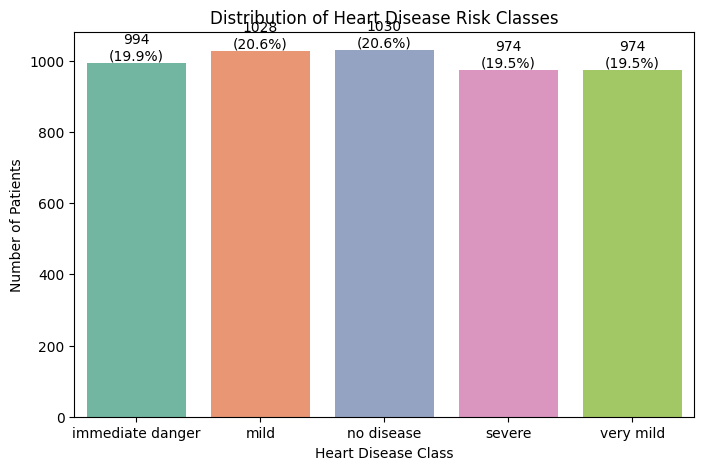

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = df['heart_disease'].value_counts().sort_index()
class_percentages = (class_counts / class_counts.sum()) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette="Set2"   # ← changed from "Blues"
)

# Add count and percentage labels
for i, (count, pct) in enumerate(zip(class_counts, class_percentages)):
    ax.text(i, count, f"{count}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10)

plt.xlabel("Heart Disease Class")
plt.ylabel("Number of Patients")
plt.title("Distribution of Heart Disease Risk Classes")
plt.show()


<h3>Correlation heatmap for numerical features</h3>

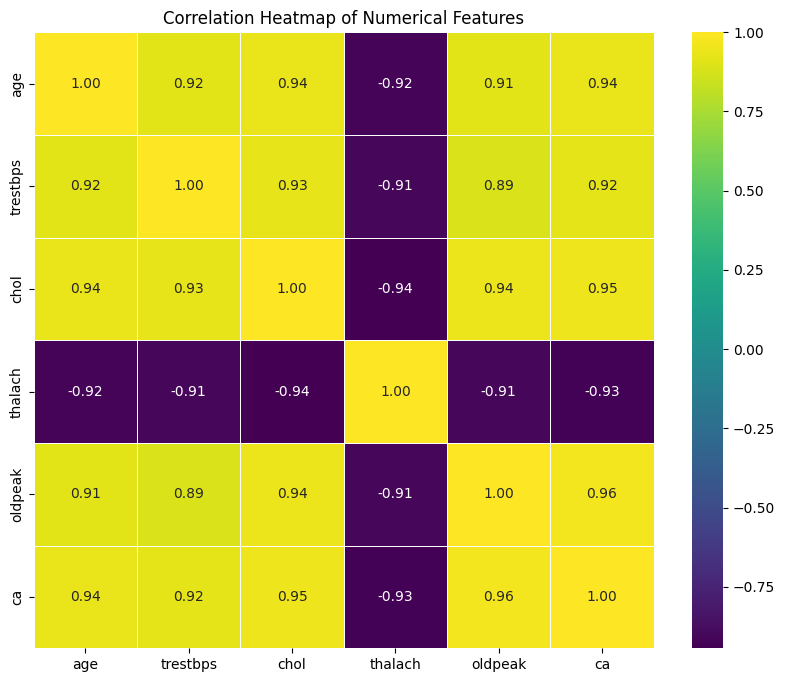

In [16]:
numerical_features = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 8))
sns.heatmap(
    numerical_features.corr(),
    annot=True,
    fmt=".2f",
    cmap="viridis",   
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()



<h3>Box plot: Age vs Heart Disease Classes</h3>

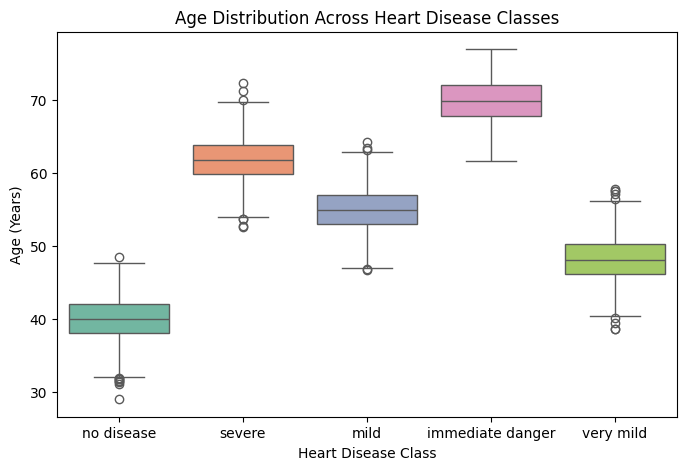

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="heart_disease",
    y="age",
    data=df,
    palette="Set2"
)

plt.xlabel("Heart Disease Class")
plt.ylabel("Age (Years)")
plt.title("Age Distribution Across Heart Disease Classes")
plt.show()

<h3>Box plot: Cholesterol vs Heart Disease Classes</h3>

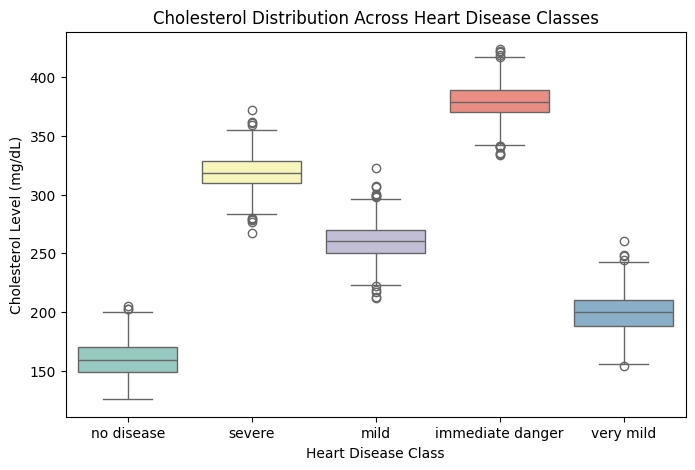

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="heart_disease",
    y="chol",
    data=df,
    palette="Set3"
)

plt.xlabel("Heart Disease Class")
plt.ylabel("Cholesterol Level (mg/dL)")
plt.title("Cholesterol Distribution Across Heart Disease Classes")
plt.show()

<h3>Horizontal bar chart of missing values</h3>

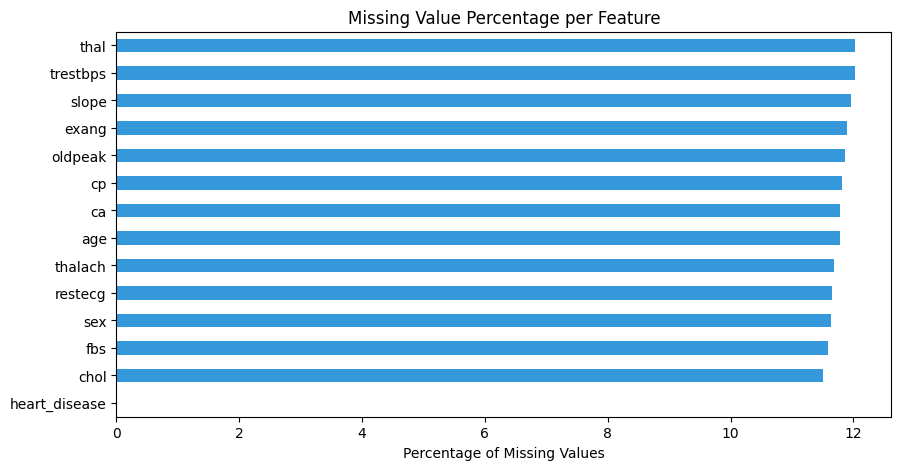

In [19]:
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
missing_percentage.plot(kind="barh", color="#3498DB")  

plt.xlabel("Percentage of Missing Values")
plt.title("Missing Value Percentage per Feature")

# Display message if no missing values
if missing_percentage.sum() == 0:
    plt.text(0.5, 0.5, "No Missing Values Found",
             ha="center", va="center", fontsize=12)

plt.show()


<h3>Separate features and target + 80/20 stratified split</h3>

In [20]:
X = df.drop(columns='heart_disease')
y = df['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

<h3>Display number of training & testing samples + percentages</h3>

In [21]:
total_samples = len(df)

train_samples = X_train.shape[0]
test_samples = X_test.shape[0]

train_pct = (train_samples / total_samples) * 100
test_pct = (test_samples / total_samples) * 100

train_samples, f"{train_pct:.2f}%", test_samples, f"{test_pct:.2f}%"

(4000, '80.00%', 1000, '20.00%')

<h3>Verify stratification using class distribution table</h3>

In [22]:
original_dist = y.value_counts(normalize=True) * 100
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100

stratification_df = pd.DataFrame({
    "Original (%)": original_dist,
    "Train (%)": train_dist,
    "Test (%)": test_dist
}).round(2).sort_index()

stratification_df

,Original (%),Train (%),Test (%)
heart_disease,,,
immediate danger,19.88,19.88,19.9
mild,20.56,20.58,20.5
no disease,20.60,20.60,20.6
severe,19.48,19.48,19.5
very mild,19.48,19.48,19.5


<h3>Identify and list all numerical features</h3>

In [23]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features

['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

<h3>Display numerical feature count</h3>

In [24]:
len(numerical_features)

6

<h3>Numerical preprocessing pipeline (imputation + scaling)</h3>

In [25]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

<h3>Identify and list all categorical features</h3>

In [26]:
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

<h3>Display categorical feature count</h3>

In [27]:
len(categorical_features)

7

<h3>Full preprocessing using ColumnTransformer + transform data</h3>

In [28]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features)
])

# Fit on training data, transform both
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

X_train_transformed.shape, X_test_transformed.shape

((4000, 25), (1000, 25))

<h3>Check transformed training data has zero missing values</h3>

In [29]:
np.isnan(X_train_transformed).sum()

0

<h3>Check transformed testing data has zero missing values</h3>

In [30]:
np.isnan(X_test_transformed).sum()

0

<h3>Verify all transformed features are numeric</h3>

In [31]:
X_train_transformed.dtype, X_test_transformed.dtype

(dtype('float64'), dtype('float64'))

<h3>Full pipeline</h3>

In [32]:
mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(max_iter=500, random_state=42))
])

<h3>Hyperparameter grid</h3>

In [33]:
mlp_param_grid = {
    'classifier__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__alpha': [0.0001, 0.001],
    'classifier__learning_rate_init': [0.001, 0.01]
}

<h3>GridSearch + training time</h3>

In [34]:
start_time = time.time()

mlp_grid = GridSearchCV(
    mlp_pipeline,
    mlp_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

mlp_grid.fit(X_train, y_train)
training_time = time.time() - start_time

<h3>Initialize results container</h3>

In [35]:
results = []

results.append({
    "Model": "MLP / ANN",
    "Best Params": mlp_grid.best_params_,
    "CV Accuracy": mlp_grid.best_score_,
    "Train Accuracy": accuracy_score(y_train, mlp_grid.predict(X_train)),
    "Test Accuracy": accuracy_score(y_test, mlp_grid.predict(X_test)),
    "Training Time (s)": training_time
})

<h3>Random Forest</h3>

In [36]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

start_time = time.time()

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
training_time = time.time() - start_time

results.append({
    "Model": "Random Forest",
    "Best Params": rf_grid.best_params_,
    "CV Accuracy": rf_grid.best_score_,
    "Train Accuracy": accuracy_score(y_train, rf_grid.predict(X_train)),
    "Test Accuracy": accuracy_score(y_test, rf_grid.predict(X_test)),
    "Training Time (s)": training_time
})

<h3>Support Vector Machine (SVM)</h3>

In [37]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

svm_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['rbf', 'linear'],
    'classifier__gamma': ['scale', 'auto']
}

start_time = time.time()

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)
training_time = time.time() - start_time

results.append({
    "Model": "SVM",
    "Best Params": svm_grid.best_params_,
    "CV Accuracy": svm_grid.best_score_,
    "Train Accuracy": accuracy_score(y_train, svm_grid.predict(X_train)),
    "Test Accuracy": accuracy_score(y_test, svm_grid.predict(X_test)),
    "Training Time (s)": training_time
})

<h3>Initialize LabelEncoder</h3>

In [38]:
le = LabelEncoder()

# Encode target labels
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Save class mapping (optional, for decoding predictions)
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class mapping:", class_mapping)


Class mapping: {'immediate danger': 0, 'mild': 1, 'no disease': 2, 'severe': 3, 'very mild': 4}


<h3>Preprocessing pipeline</h3>

In [39]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', KNeighborsClassifier())
])

knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

start_time = time.time()

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit using encoded target
knn_grid.fit(X_train, y_train_encoded)
training_time = time.time() - start_time

results.append({
    "Model": "KNN",
    "Best Params": knn_grid.best_params_,
    "CV Accuracy": knn_grid.best_score_,
    "Train Accuracy": accuracy_score(y_train_encoded, knn_grid.predict(X_train)),
    "Test Accuracy": accuracy_score(y_test_encoded, knn_grid.predict(X_test)),
    "Training Time (s)": training_time
})


In [40]:
mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(max_iter=500))
])

mlp_param_grid = {
    'classifier__hidden_layer_sizes': [(50,), (100,), (50,50)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__solver': ['adam', 'sgd'],
    'classifier__learning_rate': ['constant', 'adaptive']
}

start_time = time.time()

mlp_grid = GridSearchCV(
    mlp_pipeline,
    mlp_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

mlp_grid.fit(X_train, y_train_encoded)
training_time = time.time() - start_time

results.append({
    "Model": "MLP / ANN",
    "Best Params": mlp_grid.best_params_,
    "CV Accuracy": mlp_grid.best_score_,
    "Train Accuracy": accuracy_score(y_train_encoded, mlp_grid.predict(X_train)),
    "Test Accuracy": accuracy_score(y_test_encoded, mlp_grid.predict(X_test)),
    "Training Time (s)": training_time
})


In [41]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5],
}

start_time = time.time()

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train_encoded)
training_time = time.time() - start_time

results.append({
    "Model": "Random Forest",
    "Best Params": rf_grid.best_params_,
    "CV Accuracy": rf_grid.best_score_,
    "Train Accuracy": accuracy_score(y_train_encoded, rf_grid.predict(X_train)),
    "Test Accuracy": accuracy_score(y_test_encoded, rf_grid.predict(X_test)),
    "Training Time (s)": training_time
})


<h3>Decode KNN predictions</h3>

In [42]:
y_pred = knn_grid.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred)
print(y_pred_labels[:10])


['mild' 'severe' 'immediate danger' 'no disease' 'no disease'
 'immediate danger' 'immediate danger' 'mild' 'immediate danger'
 'no disease']


<h3>Gradient Boosting</h3>

In [43]:
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 5]
}

start_time = time.time()

gb_grid = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)
training_time = time.time() - start_time

results.append({
    "Model": "Gradient Boosting",
    "Best Params": gb_grid.best_params_,
    "CV Accuracy": gb_grid.best_score_,
    "Train Accuracy": accuracy_score(y_train, gb_grid.predict(X_train)),
    "Test Accuracy": accuracy_score(y_test, gb_grid.predict(X_test)),
    "Training Time (s)": training_time
})

<h3>Final Model Comparison Table </h3>

In [44]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="CV Accuracy", ascending=False)

,Model,Best Params,CV Accuracy,Train Accuracy,Test Accuracy,Training Time (s)
1,Random Forest,"{'classifier__max_depth': None, 'classifier__m...",0.99950,1.0,0.999,6.634550
5,Random Forest,"{'classifier__max_depth': None, 'classifier__m...",0.99950,1.0,0.999,6.360769
6,Gradient Boosting,"{'classifier__learning_rate': 0.1, 'classifier...",0.99950,1.0,0.999,67.582218
2,SVM,"{'classifier__C': 10, 'classifier__gamma': 'sc...",0.99875,1.0,0.998,1.243977
0,MLP / ANN,"{'classifier__activation': 'relu', 'classifier...",0.99850,1.0,0.997,45.619834
4,MLP / ANN,"{'classifier__activation': 'relu', 'classifier...",0.99850,1.0,0.998,83.323882
3,KNN,"{'classifier__metric': 'manhattan', 'classifie...",0.99625,1.0,0.997,1.618722


<h3>Create comparison table with overfitting gap</h3>

In [45]:
comparison_df = results_df.copy()

comparison_df["Overfitting Gap"] = (
    comparison_df["Train Accuracy"] - comparison_df["Test Accuracy"]
)

comparison_df = comparison_df[[
    "Model",
    "CV Accuracy",
    "Train Accuracy",
    "Test Accuracy",
    "Overfitting Gap"
]]

<h3>Define rule to classify model fit status</h3>

In [46]:
def classify_model(row):
    if row["Overfitting Gap"] > 0.05:
        return "Overfit"
    elif row["Test Accuracy"] < (row["CV Accuracy"] - 0.05):
        return "Underfit"
    else:
        return "Best fit"

comparison_df["Status"] = comparison_df.apply(classify_model, axis=1)

<h3>Sort table by Test Accuracy (descending)</h3>

In [47]:
comparison_df = comparison_df.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,CV Accuracy,Train Accuracy,Test Accuracy,Overfitting Gap,Status
0,Random Forest,0.99950,1.0,0.999,0.001,Best fit
1,Random Forest,0.99950,1.0,0.999,0.001,Best fit
2,Gradient Boosting,0.99950,1.0,0.999,0.001,Best fit
3,SVM,0.99875,1.0,0.998,0.002,Best fit
4,MLP / ANN,0.99850,1.0,0.998,0.002,Best fit
5,MLP / ANN,0.99850,1.0,0.997,0.003,Best fit
6,KNN,0.99625,1.0,0.997,0.003,Best fit


<h3>Select and display the best model</h3>

In [48]:
best_model_row = comparison_df.iloc[0]

best_model_name = best_model_row["Model"]
best_model_test_accuracy = best_model_row["Test Accuracy"]

best_model_name, best_model_test_accuracy

('Random Forest', 0.999)

<h3>Dictionary mapping model names to fitted GridSearch objects</h3>

In [49]:
model_grids = {
    "MLP / ANN": mlp_grid,
    "Random Forest": rf_grid,
    "SVM": svm_grid,
    "KNN": knn_grid,
    "Gradient Boosting": gb_grid
}

best_model = model_grids[best_model_name].best_estimator_


<h3>Decode numeric predictions to original labels</h3>

In [50]:
y_pred_labels = le.inverse_transform(y_pred)

y_test_labels = y_test.copy()  

report = classification_report(
    y_test_labels,
    y_pred_labels,
    target_names=le.classes_,  
    output_dict=False
)

print("Classification Report for Best Model:\n")
print(report)


Classification Report for Best Model:

                  precision    recall  f1-score   support

immediate danger       1.00      0.98      0.99       199
            mild       1.00      1.00      1.00       205
      no disease       1.00      1.00      1.00       206
          severe       0.98      1.00      0.99       195
       very mild       1.00      1.00      1.00       195

        accuracy                           1.00      1000
       macro avg       1.00      1.00      1.00      1000
    weighted avg       1.00      1.00      1.00      1000



<h3>Decode numeric predictions to original string labels</h3>

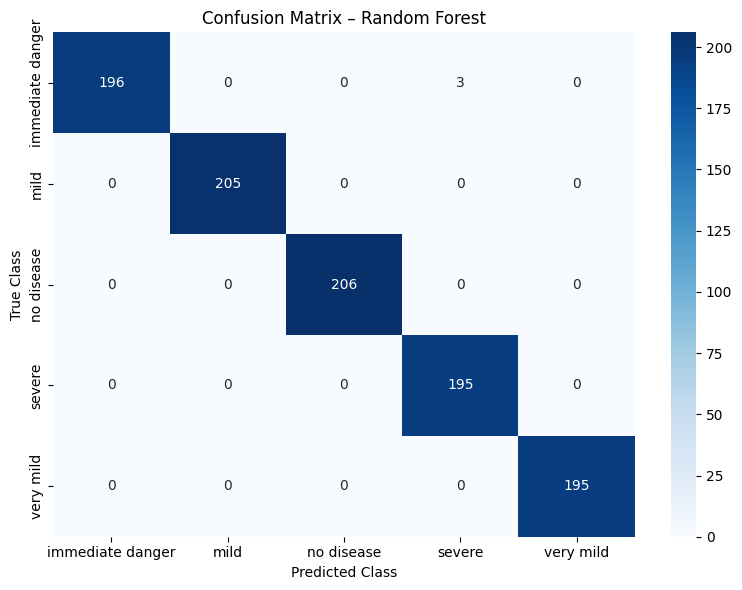

In [51]:
y_pred_labels = le.inverse_transform(y_pred)


y_test_labels = y_test.copy()

cm = confusion_matrix(y_test_labels, y_pred_labels)


plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,   
    yticklabels=le.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Confusion Matrix – {best_model_name}")

plt.tight_layout()
plt.savefig("confusion_matrix_best_model.png", dpi=300)
plt.show()


<h3>Decode numeric predictions to original string labels</h3>

In [52]:
y_pred_labels = le.inverse_transform(y_pred)

y_test_labels = y_test.copy()

report_dict = classification_report(
    y_test_labels,
    y_pred_labels,
    target_names=le.classes_,   
    output_dict=True
)


report_df = pd.DataFrame(report_dict).T.iloc[:5][
    ["precision", "recall", "f1-score"]
]

print("Per-Class Precision, Recall & F1-Score:")
display(report_df)


highest_precision_class = report_df['precision'].idxmax()
lowest_recall_class = report_df['recall'].idxmin()

print(f"\nClass with highest precision: {highest_precision_class}")
print(f"Class with lowest recall: {lowest_recall_class}")


Per-Class Precision, Recall & F1-Score:


,precision,recall,f1-score
immediate danger,1.000000,0.984925,0.992405
mild,1.000000,1.000000,1.000000
no disease,1.000000,1.000000,1.000000
severe,0.984848,1.000000,0.992366
very mild,1.000000,1.000000,1.000000



Class with highest precision: immediate danger
Class with lowest recall: immediate danger


<h3>Access the classifier from the pipeline</h3>

Supports feature importance: True
Top 10 Features by Importance:


,Feature,Importance
4,num__oldpeak,0.142433
5,num__ca,0.135823
10,cat__cp_Non-Anginal Pain,0.084459
2,num__chol,0.081209
23,cat__thal_Normal,0.065213
11,cat__cp_Typical Angina,0.064460
22,cat__thal_Fixed defect,0.063086
9,cat__cp_Atypical Angina,0.054971
24,cat__thal_Reversible defect,0.043049
19,cat__slope_Downsloping,0.041658


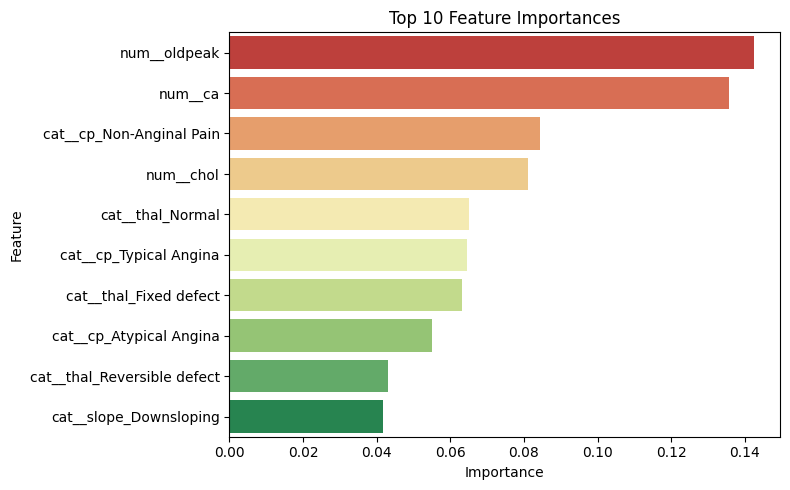

In [53]:

classifier = best_model.named_steps["classifier"]

has_feature_importance = hasattr(classifier, "feature_importances_")
print("Supports feature importance:", has_feature_importance)

if has_feature_importance:
   
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    
    
    importances = classifier.feature_importances_
    
   
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)
    
   
    print("Top 10 Features by Importance:")
    display(feature_importance_df.head(10))

    plt.figure(figsize=(8, 5))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=feature_importance_df.head(10),
        palette="RdYlGn"

    )
    plt.title("Top 10 Feature Importances")
    plt.tight_layout()
    plt.show()


<h3>Create deployment directory if it doesn't exist</h3>

In [54]:
deploy_dir = "deployment"
os.makedirs(deploy_dir, exist_ok=True)


joblib.dump(best_model, os.path.join(deploy_dir, "heart_disease_model.pkl"))

print("Model pipeline saved successfully!")


Model pipeline saved successfully!


<h3>Save all feature column names</h3>

In [55]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

with open(os.path.join(deploy_dir, "feature_names.txt"), "w") as f:
    for feature in feature_names:
        f.write(feature + "\n")

class_names = ["No disease", "Very mild", "Mild", "Severe", "Immediate danger"]

with open(os.path.join(deploy_dir, "class_names.txt"), "w") as f:
    for cls in class_names:
        f.write(cls + "\n")

<h3>Load the saved model</h3>

In [56]:

loaded_model = joblib.load(os.path.join(deploy_dir, "heart_disease_model.pkl"))


random_idx = np.random.choice(len(X_test), 5, replace=False)
X_random = X_test.iloc[random_idx]
y_random_actual = y_test.iloc[random_idx]

y_random_pred = loaded_model.predict(X_random)


verification_df1 = pd.DataFrame({
    "Actual Class": y_random_actual.values,  
    "Predicted Class": y_random_pred        
}, index=X_random.index)

verification_df1


,Actual Class,Predicted Class
3667,no disease,2
2761,mild,1
1476,mild,1
2789,immediate danger,0
1350,no disease,2


<h3>Make sure all columns exist and match training data</h3>

In [57]:

new_patients = pd.DataFrame([
   {
        "age": 45, "trestbps": 120, "chol": 180, "thalach": 170,
        "oldpeak": 0.4, "sex": 0, "cp": 1, "thal": 2,
        "restecg": 1, "slope": 2, "exang": 0, "ca": 0, "fbs": 0
    },
    {
        "age": 68, "trestbps": 160, "chol": 270, "thalach": 130,
        "oldpeak": 2.8, "sex": 1, "cp": 3, "thal": 3,
        "restecg": 2, "slope": 1, "exang": 1, "ca": 3, "fbs": 1
    },
    {
        "age": 57, "trestbps": 135, "chol": 210, "thalach": 155,
        "oldpeak": 1.5, "sex": 1, "cp": 2, "thal": 2,
        "restecg": 0, "slope": 2, "exang": 0, "ca": 1, "fbs": 0
    }
])

# Predict classes and probabilities
pred_classes = loaded_model.predict(new_patients)
pred_probs = loaded_model.predict_proba(new_patients)

# Create verification DataFrame
verification_df2 = new_patients.copy()
verification_df2["Actual Class"] = pred_classes  # already string labels

# Add probability for each class
for idx, cls in enumerate(le.classes_):
    verification_df2[f"Prob_{cls}"] = pred_probs[:, idx]

verification_df2


,age,trestbps,chol,thalach,oldpeak,sex,cp,thal,restecg,slope,exang,ca,fbs,Actual Class,Prob_immediate danger,Prob_mild,Prob_no disease,Prob_severe,Prob_very mild
0,45,120,180,170,0.4,0,1,2,1,2,0,0,0,2,0.010000,0.015000,0.600881,0.040000,0.334119
1,68,160,270,130,2.8,1,3,3,2,1,1,3,1,0,0.372333,0.033125,0.150000,0.214542,0.230000
2,57,135,210,155,1.5,1,2,2,0,2,0,1,0,4,0.012833,0.150000,0.339417,0.107167,0.390583
